## EVTOL & Passenger arrival time distribution

In [14]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
# ============================================================
#  eVTOL Stochastic Scheduling - Global Configuration
# ============================================================

# -----------------------------
# Simulation Settings
# -----------------------------
BASE_PRICE = 0.1363          # Base electricity price ($/kWh)
M_PEAK = 1.8                 # Peak-hour multiplier
M_SHOULDER = 1.05            # Shoulder-hour multiplier
M_OFF = 0.7                  # Off-peak multiplier

# -----------------------------
# eVTOL & Battery Parameters
# -----------------------------
SOC_MIN = 70.0               # Minimum required state of charge (%)
BATTERY_CAPACITY = 150.0     # Battery capacity (kWh)
CHARGING_RATE = 125          # Charging power (kW)
NUM_DESTINATIONS = 5         # Number of passenger destinations
EVTOL_CAPACITY = 4           # Max passengers per eVTOL

# -----------------------------
# Scenario Generation Parameters
# -----------------------------
N_SCENARIOS = 30             # Number of initial scenarios to generate
TARGET_SCENARIOS = 2         # Reduced representative scenarios after filtering
HORIZON_MINUTES = 240        # 4 Hours  from 240-480
BIN_SIZE = 10                #  10-min resolution

# -----------------------------
# Model Parameters
# -----------------------------
M_FACILITIES = 3             # Number of charging facilities
L_PERIODS = 24                # Number of 10-min periods (240 min = 24×10)
LOS = 2                      # Max waiting time (Level of Service = 20 Min )
UNSERVED_PENALTY = 10        # Penalty cost ($) per unserved passenger

# -----------------------------
# Discount Function Parameters
# -----------------------------
DISCOUNT_BREAKPOINTS = [0, 1, 2]    # Waiting time thresholds (periods)
DISCOUNT_VALUES = [0, 0.05, 0.15]   # Discount fractions at breakpoints

# -----------------------------
# Fare Structure
# -----------------------------
DESTINATION_FARES = {
    1: 160,    # Destination 1 fare ($)
    2: 185,    # Destination 2 fare ($)
    3: 225,     # Destination 3 fare ($)
    4: 265,     # Destination 4 fare ($)
    5: 300     # Destination 5 fare ($)
}

# -----------------------------
# Randomization Control
# -----------------------------
SEED = 60                      # Random seed for reproducibility


In [15]:
# ------------------------------------------------------------
#  Energy Price Function 
# ------------------------------------------------------------
def energy_price_per_kWh(t, base=BASE_PRICE, m_peak=M_PEAK,
                         m_shoulder=M_SHOULDER, m_off=M_OFF):
    """
    Time-of-Use (TOU) pricing function.
    t : float
        Hour of the day [0, 24).
    Returns
    -------
    float
        Electricity price in $/kWh.
    """
    if not (0 <= t < 24):
        raise ValueError("t must be in [0,24)")
    
    # Peak period: 4–9 pm
    if 16 <= t < 21:
        return base * m_peak
    # Off-peak: midnight–6 am, 9 pm–midnight
    elif 0 <= t < 6 or 21 <= t < 24:
        return base * m_off
    # Shoulder period: rest of the day
    else:
        return base * m_shoulder

# ------------------------------------------------------------
# 🚁 eVTOL & Passenger Simulation
# ------------------------------------------------------------
def simulate_evtol_and_passengers(seed=SEED,
                                  soc_min=SOC_MIN,
                                  battery_capacity=BATTERY_CAPACITY,
                                  charging_rate=CHARGING_RATE,
                                  num_destinations=NUM_DESTINATIONS,
                                  destination_fares=DESTINATION_FARES,
                                  plot=True):
    """
    Simulate eVTOL and passenger arrivals over a 1-hour window.
    Returns base data for subsequent stochastic modeling.
    """

    np.random.seed(seed)
    random.seed(seed)

    # 1. Passenger arrival times (minutes)
    passenger_arrivals = np.concatenate([
        np.random.normal(400, 85, 320),
        np.random.normal(1050, 95, 310),
        np.random.normal(800, 250, 220)
    ])

    # 2. eVTOL arrival times (minutes)
    evtol_arrivals = np.concatenate([
        np.random.normal(400, 90, 310),
        np.random.normal(600, 70, 120),
        np.random.normal(800, 80, 120),
        np.random.normal(1000, 60, 220),
        np.random.normal(1200, 70, 60)
    ])

    # Keep arrivals within [0, 60)
    passenger_arrivals = passenger_arrivals[(passenger_arrivals >= 240) & (passenger_arrivals < 480)]
    evtol_arrivals = evtol_arrivals[(evtol_arrivals >= 240) & (evtol_arrivals < 480)]

    # 3. Assign random SoC levels
    SoC = {j: random.uniform(20, 60) for j in range(len(evtol_arrivals))}

    # 4. Charging simulation
    charging_cost, charging_periods, finish_period = {}, {}, {}

    for j, arrival_min in enumerate(evtol_arrivals):
        # Convert to hour-of-day for pricing
        t_hour = arrival_min / 60.0

        if SoC[j] < soc_min:
            charge_needed = battery_capacity * ((soc_min - SoC[j]) / 100.0)
            hours_to_charge = charge_needed / charging_rate
            periods_to_charge = int(hours_to_charge * 6) + 1
            charging_periods[j] = periods_to_charge

            total_cost = 0.0
            current_time_min = arrival_min
            remaining_periods = periods_to_charge

            while remaining_periods > 0 and current_time_min < 480:
                # ✅ Convert current minute → hour for TOU pricing
                price = energy_price_per_kWh(current_time_min / 60.0)
                energy_this_period = charging_rate / 6
                total_cost += energy_this_period * price
                current_time_min += 10
                remaining_periods -= 1

            charging_cost[j] = total_cost
            finish_period[j] = current_time_min
        else:
            charging_periods[j] = 0
            finish_period[j] = arrival_min
            charging_cost[j] = 0

    # 5. Passenger destinations & fares
    destination_of_passenger = {k: random.randint(1, num_destinations)
                                for k in range(len(passenger_arrivals))}
    fare_of_passenger = {k: destination_fares[destination_of_passenger[k]]
                         for k in range(len(passenger_arrivals))}

    # 6. Optional Plots
    if plot:
        fig, axs = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
        axs[0].hist(passenger_arrivals, bins=24, alpha=0.7, color='blue', edgecolor='black')
        axs[0].set_ylabel("Passenger Count")
        axs[0].set_title("Passenger Arrivals (10-min bins)")
        axs[0].grid(True, alpha=0.3)

        axs[1].hist(evtol_arrivals, bins=24, alpha=0.7, color='green', edgecolor='black')
        axs[1].set_xlabel("Arrival Time (minutes)")
        axs[1].set_ylabel("eVTOL Count")
        axs[1].set_title("eVTOL Arrivals (10-min bins)")
        axs[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # 7. Return structured results
    return {
        "passenger_arrivals": passenger_arrivals,
        "evtol_arrivals": evtol_arrivals,
        "SoC": SoC,
        "charging_periods": charging_periods,
        "finish_charging": finish_period,
        "charging_cost": charging_cost,
        "destinations": destination_of_passenger,
        "fares": fare_of_passenger
    }

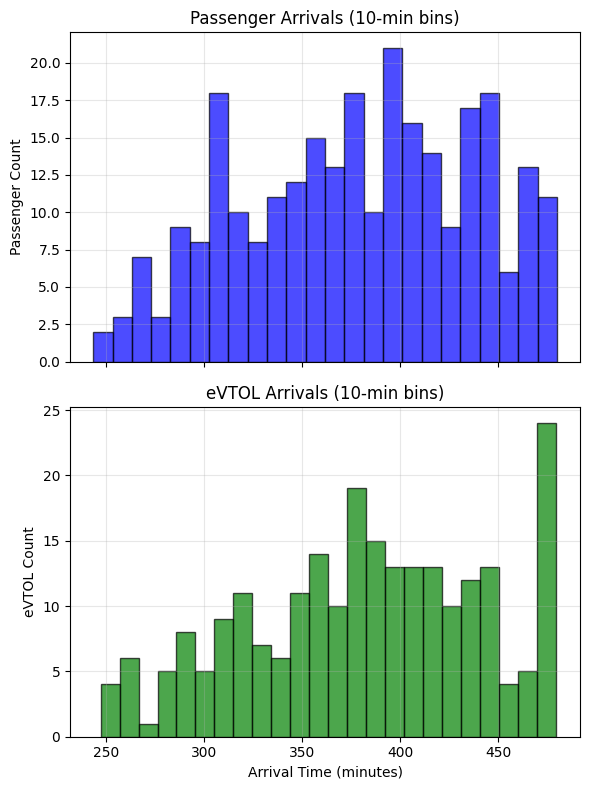

SIMULATION SUMMARY
Passengers generated: 272
eVTOLs generated:     238

eVTOL SoC and Charging Details:
  eVTOL 0: SoC=32.3%, ChargePeriods=3, Cost=$8.94
  eVTOL 1: SoC=43.1%, ChargePeriods=2, Cost=$3.98
  eVTOL 2: SoC=30.6%, ChargePeriods=3, Cost=$6.96
  eVTOL 3: SoC=52.3%, ChargePeriods=2, Cost=$5.96
  eVTOL 4: SoC=38.7%, ChargePeriods=3, Cost=$7.95
  eVTOL 5: SoC=33.3%, ChargePeriods=3, Cost=$2.98
  eVTOL 6: SoC=55.9%, ChargePeriods=2, Cost=$3.98
  eVTOL 7: SoC=51.7%, ChargePeriods=2, Cost=$3.98
  eVTOL 8: SoC=54.4%, ChargePeriods=2, Cost=$5.96
  eVTOL 9: SoC=46.6%, ChargePeriods=2, Cost=$4.97
  eVTOL 10: SoC=27.4%, ChargePeriods=4, Cost=$7.95
  eVTOL 11: SoC=35.6%, ChargePeriods=3, Cost=$7.95
  eVTOL 12: SoC=29.6%, ChargePeriods=3, Cost=$6.96
  eVTOL 13: SoC=51.7%, ChargePeriods=2, Cost=$5.96
  eVTOL 14: SoC=20.4%, ChargePeriods=4, Cost=$11.93
  eVTOL 15: SoC=51.6%, ChargePeriods=2, Cost=$3.98
  eVTOL 16: SoC=26.7%, ChargePeriods=4, Cost=$11.93
  eVTOL 17: SoC=32.2%, ChargePeriods=

In [16]:
# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    """
    Entry point for simulation stage.
    Generates and visualizes base passenger & eVTOL arrival data.
    """

    # ------------------------------------------------------------
    # 🚀 Run Base Simulation
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        num_destinations=NUM_DESTINATIONS,
        destination_fares=DESTINATION_FARES,
        plot=True
    )

    # ------------------------------------------------------------
    # 📊 Display Summary
    # ------------------------------------------------------------
    print("=" * 70)
    print("SIMULATION SUMMARY")
    print("=" * 70)
    print(f"Passengers generated: {len(results['passenger_arrivals'])}")
    print(f"eVTOLs generated:     {len(results['evtol_arrivals'])}\n")

    print("eVTOL SoC and Charging Details:")
    for j, soc in results["SoC"].items():
        print(f"  eVTOL {j}: SoC={soc:.1f}%, "
              f"ChargePeriods={results['charging_periods'][j]}, "
              f"Cost=${results['charging_cost'][j]:.2f}")

    print("\nPassenger Destinations & Fares:")
    for k, dest in results["destinations"].items():
        print(f"  Passenger {k}: Destination={dest}, "
              f"Fare=${results['fares'][k]}")


## Joint Demand Scenario Generation with NHPP

In [17]:
# ============================================================
#  Joint Passenger–eVTOL Demand Scenario Generator
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


# ------------------------------------------------------------
# 🔄 Joint Demand Scenario Generator (NHPP-based)
# ------------------------------------------------------------
def generate_joint_demand_scenarios(passenger_arrivals,
                                    evtol_arrivals,
                                    n_scenarios=N_SCENARIOS,
                                    horizon_minutes=HORIZON_MINUTES,
                                    bin_size=BIN_SIZE,
                                    plot=True):
    """
    Generate joint demand scenarios (NHPP-based) for passenger and eVTOL arrivals.
    Works for any time horizon (e.g., 24h with 10-min bins = 144 periods).

    Parameters
    ----------
    passenger_arrivals : array-like
        Arrival times of passengers (minutes).
    evtol_arrivals : array-like
        Arrival times of eVTOLs (minutes).
    n_scenarios : int, default=N_SCENARIOS
        Number of demand scenarios to generate.
    horizon_minutes : int, default=HORIZON_MINUTES
        Total simulation window (in minutes).
    bin_size : int, default=BIN_SIZE
        Discretization resolution (in minutes per bin).
    plot : bool, default=True
        If True, show scenario plots and baseline rate visualization.

    Returns
    -------
    scenarios : list of dict
        Each dict contains scenario-specific arrival rates and realizations:
        - id : scenario index
        - lambda_a : passenger rate vector (per time bin)
        - lambda_e : eVTOL rate vector (per time bin)
        - a_t : simulated passenger counts per time bin
        - e_t : simulated eVTOL counts per time bin
        - total_passengers : total passenger demand in this scenario
        - total_evtols : total eVTOL demand in this scenario
        - theoretical_corr : theoretical correlation baseline
        - empirical_corr : realized correlation in this scenario
    """

    # ------------------------------------------------------------
    # 1. Define Time Horizon and Bins (240–480 min window)
    # ------------------------------------------------------------
    start_min, end_min = 240, 480
    l_periods = (end_min - start_min) // BIN_SIZE
    bin_edges = np.linspace(start_min, end_min, l_periods + 1)
    time_periods = np.arange(1, l_periods + 1)

    # ------------------------------------------------------------
    # 2. Histogram Counts per Bin
    # ------------------------------------------------------------
    passenger_hist, _ = np.histogram(passenger_arrivals, bins=bin_edges)
    evtol_hist, _ = np.histogram(evtol_arrivals, bins=bin_edges)

    # ------------------------------------------------------------
    # 3. Smooth Baseline Rates (Gaussian)
    # ------------------------------------------------------------
    f_a = gaussian_filter1d(passenger_hist.astype(float), sigma=2)
    f_e = gaussian_filter1d(evtol_hist.astype(float), sigma=2)
    f_a, f_e = np.maximum(f_a, 0), np.maximum(f_e, 0)

    # ------------------------------------------------------------
    # 4. Estimate Residual Variance
    # ------------------------------------------------------------
    residuals_a = passenger_hist - f_a
    residuals_e = evtol_hist - f_e
    sigma_epsilon_sq = min(np.var(residuals_a), np.var(residuals_e))

    # ------------------------------------------------------------
    # 5. Generate Scenarios with Correlated Noise
    # ------------------------------------------------------------
    scenarios = []
    for scenario_id in range(N_SCENARIOS):
        epsilon_t = np.random.normal(0, np.sqrt(sigma_epsilon_sq), l_periods)

        lambda_a_omega = np.maximum(f_a + epsilon_t, 0)
        lambda_e_omega = np.maximum(f_e + epsilon_t, 0)

        a_t_omega = np.random.poisson(lambda_a_omega)
        e_t_omega = np.random.poisson(lambda_e_omega)

        numerator = sigma_epsilon_sq
        denominator = np.sqrt((f_a + sigma_epsilon_sq) * (f_e + sigma_epsilon_sq))
        theoretical_corr = np.mean(numerator / denominator)
        empirical_corr = np.corrcoef(a_t_omega, e_t_omega)[0, 1]

        scenarios.append({
            "id": scenario_id,
            "lambda_a": lambda_a_omega,
            "lambda_e": lambda_e_omega,
            "a_t": a_t_omega,
            "e_t": e_t_omega,
            "total_passengers": np.sum(a_t_omega),
            "total_evtols": np.sum(e_t_omega),
            "theoretical_corr": theoretical_corr,
            "empirical_corr": empirical_corr
        })

    # ------------------------------------------------------------
    # 6. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        fig, axes = plt.subplots(3, 2, figsize=(12, 10))
        fig.suptitle("Joint Demand Scenarios (Sample of 6, 240–480 min)", fontsize=16)

        for i, scenario in enumerate(scenarios[:6]):
            ax = axes[i // 2, i % 2]
            ax.plot(time_periods, scenario["a_t"], "o-", label="Passengers", color="blue")
            ax.plot(time_periods, scenario["e_t"], "s-", label="eVTOLs", color="green")
            ax.set_title(f"Scenario {scenario['id']+1}")
            ax.set_xlabel("Time Period (10-min bins)")
            ax.set_ylabel("Count")
            ax.legend()
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.plot(time_periods, f_a, "o-", label="Baseline Passenger Rate", color="blue")
        plt.plot(time_periods, f_e, "s-", label="Baseline eVTOL Rate", color="green")
        plt.title("Baseline Arrival Rates (Smoothed, 240–480 min)")
        plt.xlabel("Time Period (10-min bins)")
        plt.ylabel("Rate")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return scenarios


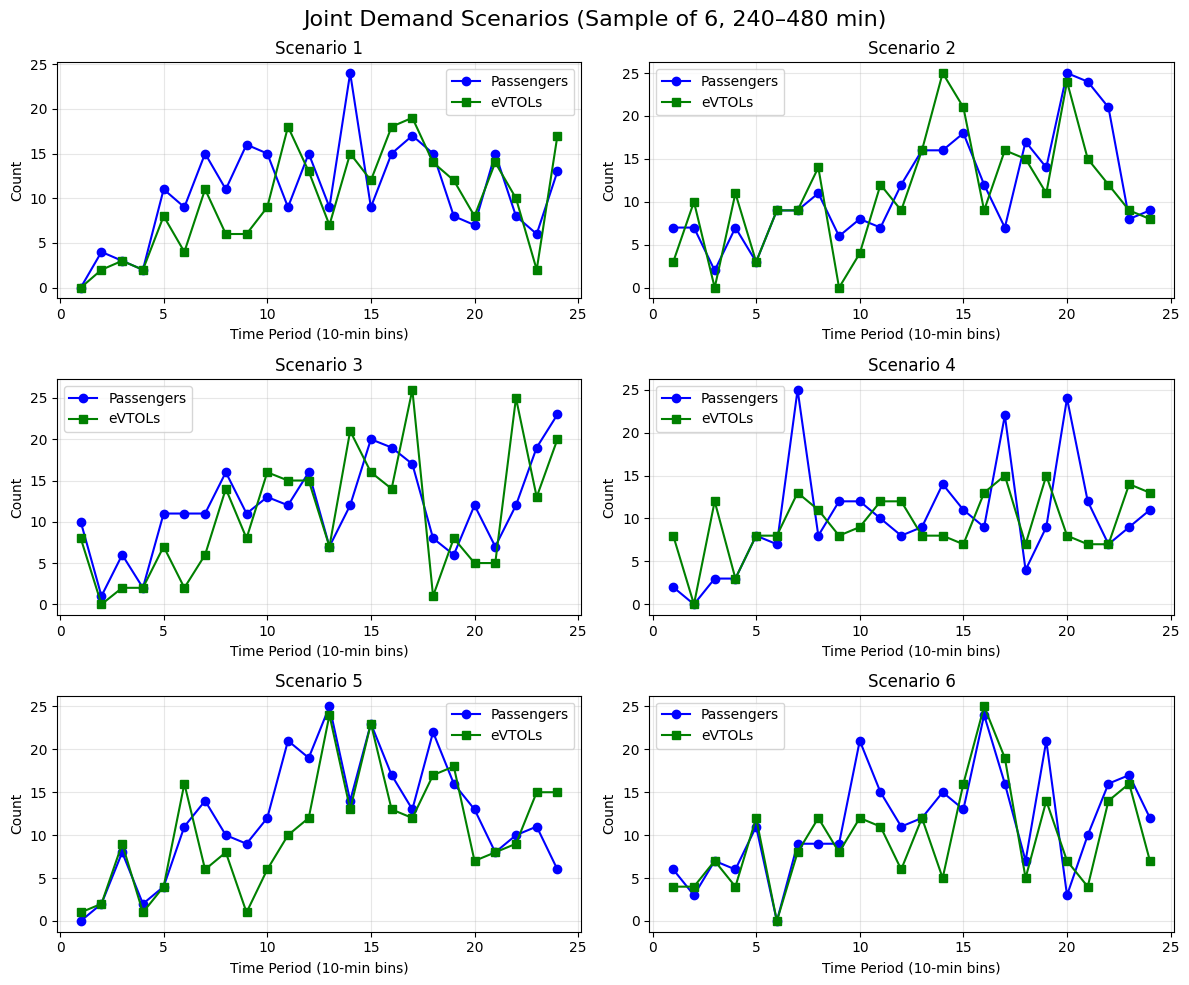

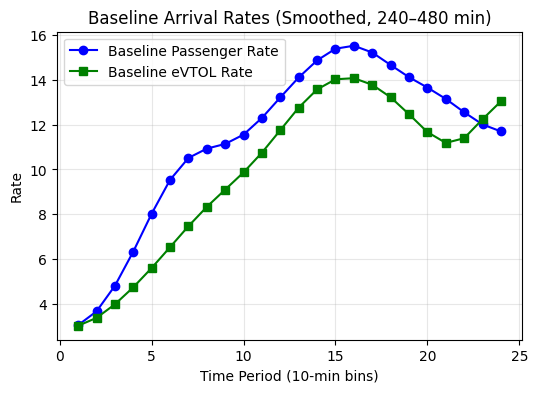


📊 JOINT DEMAND SCENARIO GENERATION SUMMARY
Generated 30 scenarios with 24 time bins.
Average passenger arrivals per scenario: 272.63
Average eVTOL arrivals per scenario: 236.47
Average empirical correlation (a_t vs e_t): 0.673


In [18]:
# ============================================================
# 🚀 Main Execution – Scenario Generation
# ============================================================
if __name__ == "__main__":

    # ----------------------------------------
    # 1. Run Base Simulation
    # ----------------------------------------
    results = simulate_evtol_and_passengers(
        seed=SEED,
        plot=False
    )

    # ----------------------------------------
    # 2. Generate Joint Demand Scenarios
    # ----------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=True
    )

    # ----------------------------------------
    # 3. Print Summary
    # ----------------------------------------
    print("\n" + "=" * 80)
    print("📊 JOINT DEMAND SCENARIO GENERATION SUMMARY")
    print("=" * 80)
    print(f"Generated {len(scenarios)} scenarios with {HORIZON_MINUTES // BIN_SIZE} time bins.")
    print(f"Average passenger arrivals per scenario: "
          f"{np.mean([s['total_passengers'] for s in scenarios]):.2f}")
    print(f"Average eVTOL arrivals per scenario: "
          f"{np.mean([s['total_evtols'] for s in scenarios]):.2f}")

    avg_corr = np.mean([s['empirical_corr'] for s in scenarios])
    print(f"Average empirical correlation (a_t vs e_t): {avg_corr:.3f}")
    print("=" * 80)


## Scenario Reduction via Backward Selection


In [19]:
# ============================================================
# Scenario Reduction with eVTOL Filtering (Backward Selection)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Backward Scenario Reduction with eVTOL Constraint
# ------------------------------------------------------------
def scenario_reduction_backward_with_evtol_filter(
        scenarios,
        target_size=TARGET_SCENARIOS,
        plot=True):
    """
    Reduce scenarios using backward selection while ensuring
    no scenarios without eVTOLs are selected.

    Parameters
    ----------
    scenarios : list
        Full set of generated scenarios (from generate_joint_demand_scenarios()).
    target_size : int, default=TARGET_SCENARIOS
        Desired number of reduced representative scenarios.
    plot : bool, default=True
        If True, generate comparative analysis plots.

    Returns
    -------
    reduced_scenarios : list
        Reduced scenario set with updated probabilities and preserved diversity.
    """

    # ------------------------------------------------------------
    # 1. Filter Scenarios with At Least One eVTOL
    # ------------------------------------------------------------
    scenarios_with_evtols = [s for s in scenarios if s['total_evtols'] > 0]

    # If too few valid scenarios, pick top by eVTOL count
    if len(scenarios_with_evtols) < target_size:
        scenarios_sorted = sorted(scenarios, key=lambda x: x['total_evtols'], reverse=True)
        scenarios_with_evtols = scenarios_sorted[:target_size]

    # ------------------------------------------------------------
    # 2. Initialize Probabilities & Feature Vectors
    # ------------------------------------------------------------
    n_original = len(scenarios_with_evtols)
    for scenario in scenarios_with_evtols:
        scenario['probability'] = 1.0 / n_original
        scenario['feature_vector'] = np.concatenate([scenario['a_t'], scenario['e_t']])

    working_scenarios = scenarios_with_evtols.copy()

    # ------------------------------------------------------------
    # 3. Backward Reduction Loop
    # ------------------------------------------------------------
    while len(working_scenarios) > target_size:
        n_current = len(working_scenarios)
        distances = np.zeros((n_current, n_current))

        # Compute pairwise Euclidean distances
        for i in range(n_current):
            for j in range(i + 1, n_current):
                dist = np.linalg.norm(
                    working_scenarios[i]['feature_vector'] -
                    working_scenarios[j]['feature_vector']
                )
                distances[i, j] = distances[j, i] = dist

        # Identify scenario with minimal cost to remove
        min_cost, remove_idx, nearest_neighbor = float('inf'), None, None
        for i in range(n_current):
            mask = np.ones(n_current, dtype=bool)
            mask[i] = False
            min_dist = np.min(distances[i, mask])
            cost = working_scenarios[i]['probability'] * min_dist

            if cost < min_cost:
                min_cost = cost
                remove_idx = i
                nearest_neighbor = np.argmin([
                    distances[i, j] if j != i else float('inf') for j in range(n_current)
                ])

        # Transfer probability to nearest neighbor, remove lowest-cost scenario
        working_scenarios[nearest_neighbor]['probability'] += \
            working_scenarios[remove_idx]['probability']
        _ = working_scenarios.pop(remove_idx)

    # ------------------------------------------------------------
    # 4. Normalize Final Probabilities
    # ------------------------------------------------------------
    total_prob = sum(s['probability'] for s in working_scenarios)
    for s in working_scenarios:
        s['probability'] /= total_prob

    # ------------------------------------------------------------
    # 5. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        l_periods = len(scenarios[0]['a_t'])
        time_periods = np.arange(1, l_periods + 1)
        colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

        fig, axes = plt.subplots(2, 2, figsize=(10, 9))
        fig.suptitle("Reduced Scenarios Analysis", fontsize=16, fontweight="bold")

        # (a) Passenger arrivals
        for i, s in enumerate(working_scenarios):
            axes[0, 0].plot(time_periods, s['a_t'], 'o-',
                            label=f"Scenario {s['id']+1} (p={s['probability']:.2f})",
                            color=colors[i % len(colors)], linewidth=2)
        axes[0, 0].set_title("Passenger Arrivals by Time Period")
        axes[0, 0].set_xlabel("Time Period (10-min intervals)")
        axes[0, 0].set_ylabel("Passenger Count")
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # (b) eVTOL arrivals
        for i, s in enumerate(working_scenarios):
            axes[0, 1].plot(time_periods, s['e_t'], 's-',
                            label=f"Scenario {s['id']+1} (p={s['probability']:.2f})",
                            color=colors[i % len(colors)], linewidth=2)
        axes[0, 1].set_title("eVTOL Arrivals by Time Period")
        axes[0, 1].set_xlabel("Time Period (10-min intervals)")
        axes[0, 1].set_ylabel("eVTOL Count")
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # (c) Scenario probabilities
        labels = [f"Scenario {s['id']+1}" for s in working_scenarios]
        probs = [s['probability'] for s in working_scenarios]
        bars = axes[1, 0].bar(labels, probs, color=colors[:len(working_scenarios)], alpha=0.7)
        axes[1, 0].set_title("Scenario Probabilities")
        axes[1, 0].set_ylabel("Probability")
        axes[1, 0].grid(True, alpha=0.3)
        for bar, prob in zip(bars, probs):
            axes[1, 0].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
                            f"{prob:.2f}", ha="center", fontweight="bold")

        # (d) Average comparison (original vs reduced)
        orig_p = [s['total_passengers'] for s in scenarios if s['total_evtols'] > 0]
        orig_e = [s['total_evtols'] for s in scenarios if s['total_evtols'] > 0]
        red_p = [s['total_passengers'] for s in working_scenarios]
        red_e = [s['total_evtols'] for s in working_scenarios]

        x = np.arange(2)
        w = 0.35
        axes[1, 1].bar(x - w / 2, [np.mean(orig_p), np.mean(orig_e)], w,
                       label="Original Avg", alpha=0.6)
        axes[1, 1].bar(x + w / 2, [np.mean(red_p), np.mean(red_e)], w,
                       label="Reduced Avg", alpha=0.8)
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(["Passengers", "eVTOLs"])
        axes[1, 1].set_title("Original vs Reduced Scenarios")
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # 6. Return Reduced Scenarios
    # ------------------------------------------------------------
    return working_scenarios


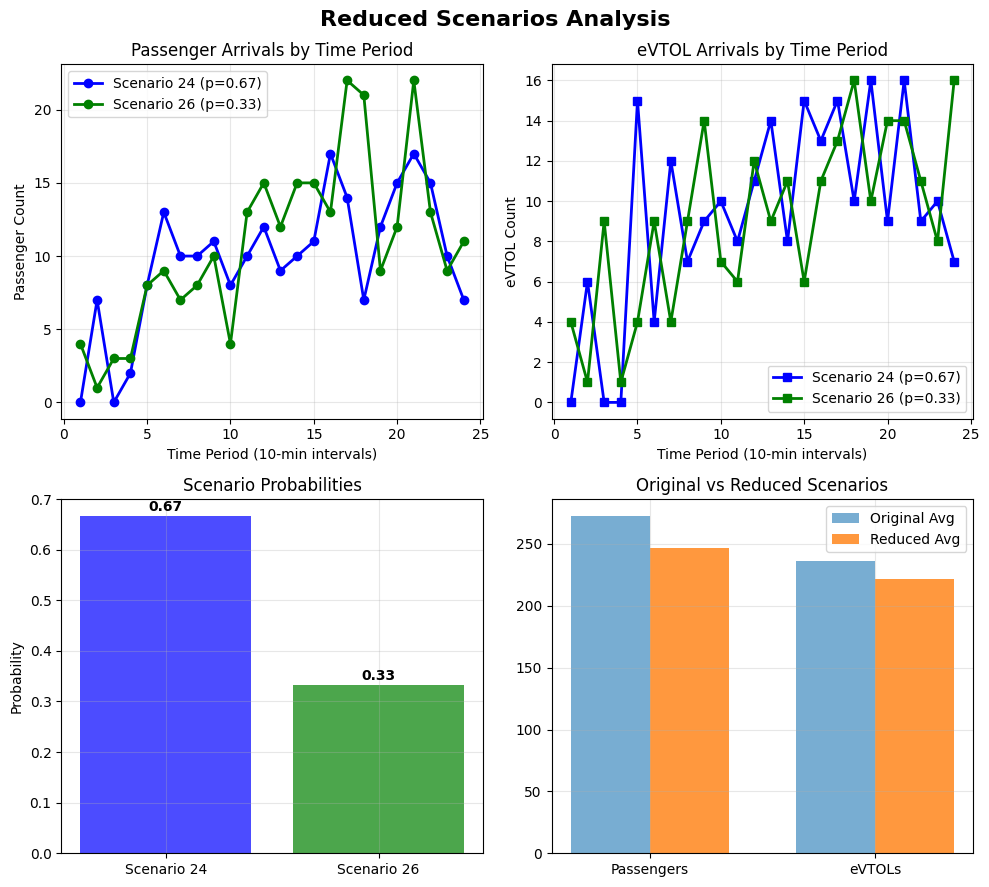


🔻 SCENARIO REDUCTION SUMMARY
Initial Scenarios: 30
Reduced to:        2 scenarios

Final Scenario Probabilities:
  Scenario 24  → p = 0.667
  Scenario 26  → p = 0.333

Average Total Passengers (Reduced): 247.00
Average Total eVTOLs (Reduced):    221.50
Average Empirical Correlation (Reduced): 0.697


In [20]:
# ============================================================
#  Main Execution – Scenario Reduction
# ============================================================
if __name__ == "__main__":

    # ----------------------------------------
    # 1. Run Base Simulation
    # ----------------------------------------
    results = simulate_evtol_and_passengers(
        seed=SEED,
        plot=False
    )

    # ----------------------------------------
    # 2. Generate Initial Joint Demand Scenarios
    # ----------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # ----------------------------------------
    # 3. Apply Backward Scenario Reduction
    # ----------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=True
    )

    # ----------------------------------------
    # 4. Summary Report
    # ----------------------------------------
    print("\n" + "=" * 80)
    print("🔻 SCENARIO REDUCTION SUMMARY")
    print("=" * 80)
    print(f"Initial Scenarios: {len(scenarios)}")
    print(f"Reduced to:        {len(reduced_scenarios)} scenarios\n")

    print("Final Scenario Probabilities:")
    for s in reduced_scenarios:
        print(f"  Scenario {s['id']+1:<3} → p = {s['probability']:.3f}")

    print("\nAverage Total Passengers (Reduced): "
          f"{np.mean([s['total_passengers'] for s in reduced_scenarios]):.2f}")
    print("Average Total eVTOLs (Reduced):    "
          f"{np.mean([s['total_evtols'] for s in reduced_scenarios]):.2f}")

    avg_corr = np.mean([s['empirical_corr'] for s in reduced_scenarios])
    print(f"Average Empirical Correlation (Reduced): {avg_corr:.3f}")
    print("=" * 80)


## Conditional Sampling of State of Charge (SoC)

In [21]:
# ============================================================
# 🔋 Conditional SoC Sampling per eVTOL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Conditional Sampling of SoC based on Passenger Load Ratios
# ------------------------------------------------------------
def conditional_soc_sampling_per_evtol(
        reduced_scenarios,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        plot=False):
    """
    Perform conditional sampling of State of Charge (SoC) for each eVTOL 
    based on passenger-to-eVTOL load ratio at arrival times.

    SoC is constrained between 20 and 60.

    Parameters
    ----------
    reduced_scenarios : list
        Scenarios reduced from scenario_reduction_backward_with_evtol_filter().
    s_base : float, default=50
        Base SoC when load ratio is 0 (midpoint of 20–60 range).
    k : float, default=12
        Scaling factor for mean SoC decrease with load ratio.
    sigma_base : float, default=3
        Base standard deviation for SoC sampling.
    sigma_scale : float, default=5
        Scaling factor for std deviation increase with load ratio.
    plot : bool, default=False
        If True, generates visualization of SoC distributions.

    Returns
    -------
    list
        The same reduced scenarios list, updated with SoC-related data:
        - scenario['rho_t_omega'] : load ratio per period
        - scenario['evtol_socs'] : dict of eVTOL ID → sampled SoC
        - scenario['evtol_arrival_periods'] : dict of eVTOL ID → arrival period
        - scenario['total_evtols_count'] : total number of eVTOLs
        - scenario['avg_load_ratio'] : average load ratio across periods
    """

    # ------------------------------------------------------------
    # 1. Iterate through Reduced Scenarios
    # ------------------------------------------------------------
    for scenario in reduced_scenarios:
        a_t_omega = scenario['a_t']  # Passenger arrivals per period
        e_t_omega = scenario['e_t']  # eVTOL arrivals per period

        # ------------------------------------------------------------
        # 2. Compute Load Ratios per Period (ρ_t_ω)
        # ------------------------------------------------------------
        rho_t_omega = np.zeros_like(a_t_omega, dtype=float)
        for t in range(len(a_t_omega)):
            if e_t_omega[t] > 0:
                rho_t_omega[t] = a_t_omega[t] / e_t_omega[t]
            else:
                # Handle zero-eVTOL periods by interpolation or carry-forward
                if 0 < t < len(a_t_omega) - 1:
                    rho_t_omega[t] = (rho_t_omega[t - 1] + rho_t_omega[t + 1]) / 2
                elif t > 0:
                    rho_t_omega[t] = rho_t_omega[t - 1]
                else:
                    rho_t_omega[t] = rho_t_omega[t + 1] if len(a_t_omega) > 1 else 1.0

        evtol_socs = {}
        evtol_arrival_periods = {}
        evtol_count = 0

        # ------------------------------------------------------------
        # 3. Assign SoC per eVTOL
        # ------------------------------------------------------------
        for t in range(len(e_t_omega)):
            for _ in range(e_t_omega[t]):
                evtol_id = evtol_count
                evtol_arrival_periods[evtol_id] = t + 1  # Period index (1-based)

                load_ratio = rho_t_omega[t]
                mu_s = s_base - k * load_ratio
                sigma_s = sigma_base + sigma_scale * load_ratio

                # Clip mean and standard deviation to avoid extreme values
                mu_s = np.clip(mu_s, 25, 55)
                sigma_s = np.clip(sigma_s, 2, 8)

                # Sample valid SoC value within [20, 60]
                sampled = False
                while not sampled:
                    soc_sample = np.random.normal(mu_s, sigma_s)
                    if 20 <= soc_sample <= 60:
                        evtol_socs[evtol_id] = soc_sample
                        sampled = True

                evtol_count += 1

        # ------------------------------------------------------------
        # 4. Store Scenario Results
        # ------------------------------------------------------------
        scenario['rho_t_omega'] = rho_t_omega
        scenario['evtol_socs'] = evtol_socs
        scenario['evtol_arrival_periods'] = evtol_arrival_periods
        scenario['total_evtols_count'] = evtol_count
        scenario['avg_load_ratio'] = np.mean(rho_t_omega)

    # ------------------------------------------------------------
    # 5. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        plt.figure(figsize=(6, 4))
        for scenario in reduced_scenarios:
            socs = list(scenario['evtol_socs'].values())
            plt.hist(socs, bins=8, alpha=0.6, edgecolor="black",
                     label=f"Scenario {scenario['id'] + 1}")
        plt.title("SoC Distribution Across Reduced Scenarios")
        plt.xlabel("State of Charge (%)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # ------------------------------------------------------------
    # 6. Return Updated Scenarios
    # ------------------------------------------------------------
    return reduced_scenarios


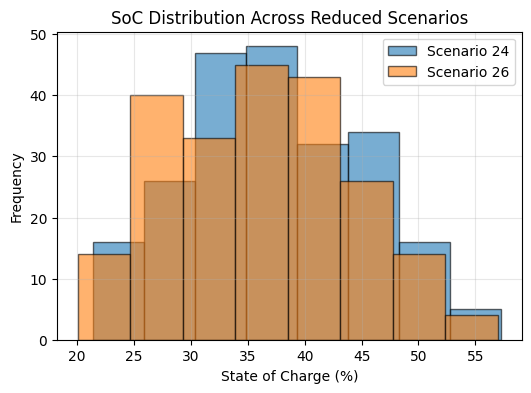


🔋 CONDITIONAL SoC SAMPLING SUMMARY
Number of Reduced Scenarios: 2

Scenario 24:
  - Total eVTOLs:     224
  - Avg Load Ratio:   1.05
  - SoC Range:        21.4% – 57.2%
  - Mean SoC:         37.5%
  - Std Dev (SoC):    7.88

Scenario 26:
  - Total eVTOLs:     219
  - Avg Load Ratio:   1.31
  - SoC Range:        20.1% – 57.0%
  - Mean SoC:         36.0%
  - Std Dev (SoC):    7.89



In [22]:
# ============================================================
# Main Execution – Conditional SoC Sampling per eVTOL
# ============================================================
if __name__ == "__main__":

    # ----------------------------------------
    # 1. Run Base Simulation
    # ----------------------------------------
    results = simulate_evtol_and_passengers(
        seed=SEED,
        plot=False
    )

    # ----------------------------------------
    # 2. Generate Initial Joint Demand Scenarios
    # ----------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # ----------------------------------------
    # 3. Apply Backward Scenario Reduction
    # ----------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )

    # ----------------------------------------
    # 4. Perform Conditional SoC Sampling
    # ----------------------------------------
    scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,          # Midpoint baseline
        k=12,               # SoC degradation scaling factor
        sigma_base=3,       # Base deviation
        sigma_scale=5,      # Variability with load ratio
        plot=True           # Visualize SoC distribution
    )

    # ----------------------------------------
    # 5. Summary Report
    # ----------------------------------------
    print("\n" + "=" * 80)
    print("🔋 CONDITIONAL SoC SAMPLING SUMMARY")
    print("=" * 80)
    print(f"Number of Reduced Scenarios: {len(scenarios_with_soc)}\n")

    for s in scenarios_with_soc:
        print(f"Scenario {s['id'] + 1}:")
        print(f"  - Total eVTOLs:     {s['total_evtols_count']}")
        print(f"  - Avg Load Ratio:   {s['avg_load_ratio']:.2f}")
        soc_values = list(s['evtol_socs'].values())
        print(f"  - SoC Range:        {min(soc_values):.1f}% – {max(soc_values):.1f}%")
        print(f"  - Mean SoC:         {np.mean(soc_values):.1f}%")
        print(f"  - Std Dev (SoC):    {np.std(soc_values):.2f}\n")

    print("=" * 80)


## Input Data Preparation for Stochastic Optimization Model

In [23]:
import random
import numpy as np

def build_stochastic_model_input(
    reduced_scenarios,
    m_facilities=M_FACILITIES,
    l_periods=L_PERIODS,
    SoC_min=SOC_MIN,
    c=BATTERY_CAPACITY,
    qr=CHARGING_RATE,
    LoS=LOS,
    eVTOL_capacity=EVTOL_CAPACITY,
    destination_fares=DESTINATION_FARES,
    verbose=True
):
    """
    Build stochastic model input for optimization based on reduced scenarios.
    
    Uses:
      - Global constants from configuration
      - energy_price_per_kWh(t): defined for hours [0, 24)
    """

    stochastic_input = {
        'scenarios': {},
        'global_parameters': {
            'm_facilities': m_facilities,
            'l_periods': l_periods,
            'SoC_min': SoC_min,
            'c': c,
            'qr': qr,
            'LoS': LoS,
            'eVTOL_capacity': eVTOL_capacity,
            'destination_fares': destination_fares
        }
    }

    # -------------------------------------------------
    # Build scenario-specific data
    # -------------------------------------------------
    for scenario in reduced_scenarios:
        sid = scenario['id']
        prob = scenario['probability']

        n_evtols = scenario['total_evtols_count']
        w_passengers = int(np.sum(scenario['a_t']))

        scenario_data = {
            'probability': prob,
            'n_evtols': n_evtols,
            'w_passengers': w_passengers,
            'evtols': {},
            'passengers': {},
            'agg_pass_demand': {}
        }

        # -------------------------------------------------
        # eVTOLs: arrival times, SoC, charging needs, costs
        # -------------------------------------------------
        evtol_arrivals = []
        for t, count in enumerate(scenario['e_t']):
            for _ in range(int(count)):
                arrival_time = (t * BIN_SIZE) + random.uniform(0, BIN_SIZE)
                evtol_arrivals.append(arrival_time)
        evtol_arrivals_sorted = sorted(evtol_arrivals)

        soc_values = [scenario['evtol_socs'][eid]
                      for eid in sorted(scenario['evtol_socs'].keys())]

        for j, arrival_time in enumerate(evtol_arrivals_sorted):
            arrival_bin = int(arrival_time // BIN_SIZE) + 1
            soc = soc_values[j] if j < len(soc_values) else random.uniform(20, 60)

            if soc < SoC_min:
                charge_needed = c * ((SoC_min - soc) / 100.0)
                hours_to_charge = charge_needed / qr
                periods_to_charge = hours_to_charge * (60 / BIN_SIZE)
                p_j = int(periods_to_charge) + 1
                finish_charging_period = min(arrival_bin + p_j, l_periods)

                total_cost, current_minute, remaining = 0, arrival_time, p_j
                while remaining > 0 and current_minute < 480:
                    # ✅ Convert minute → hour for pricing
                    current_hour = current_minute / 60.0
                    energy_this_period = min(1, remaining) * (qr / (60 / BIN_SIZE))
                    total_cost += energy_this_period * energy_price_per_kWh(current_hour)
                    current_minute += BIN_SIZE
                    remaining -= 1
            else:
                p_j, finish_charging_period, total_cost = 0, arrival_bin, 0

            scenario_data['evtols'][j] = {
                'arrival_time': arrival_time,
                'arrival_bin': arrival_bin,
                'soc': soc,
                'charging_periods': p_j,
                'finish_charging_period': finish_charging_period,
                'charging_cost': total_cost
            }

        # -------------------------------------------------
        # Passengers: arrivals, destinations, fares
        # -------------------------------------------------
        passenger_arrivals = []
        for t, count in enumerate(scenario['a_t']):
            for _ in range(int(count)):
                arrival_time = (t * BIN_SIZE) + random.uniform(0, BIN_SIZE)
                passenger_arrivals.append(arrival_time)
        passenger_arrivals_sorted = sorted(passenger_arrivals)

        dest_of_passenger, fare_of_passenger = {}, {}
        for k, arrival_time in enumerate(passenger_arrivals_sorted):
            dest = random.randint(1, len(destination_fares))
            dest_of_passenger[k] = dest
            fare_of_passenger[k] = destination_fares[dest]
            arrival_bin = int(arrival_time // BIN_SIZE) + 1

            scenario_data['passengers'][k] = {
                'arrival_time': arrival_time,
                'arrival_bin': arrival_bin,
                'destination': dest,
                'fare': fare_of_passenger[k]
            }

        # -------------------------------------------------
        # Aggregated Passenger Demand (time, destination)
        # -------------------------------------------------
        agg_pass_demand = {(t, d): 0 for t in range(1, l_periods + 1)
                                     for d in destination_fares.keys()}
        for pdata in scenario_data['passengers'].values():
            t = pdata['arrival_bin']
            d = pdata['destination']
            agg_pass_demand[(t, d)] += 1
        scenario_data['agg_pass_demand'] = agg_pass_demand

        stochastic_input['scenarios'][sid] = scenario_data

    # -------------------------------------------------
    # Scenario Ranges
    # -------------------------------------------------
    all_evtols = [s['n_evtols'] for s in stochastic_input['scenarios'].values()]
    all_passengers = [s['w_passengers'] for s in stochastic_input['scenarios'].values()]
    stochastic_input['global_parameters']['n_evtols_range'] = (min(all_evtols), max(all_evtols))
    stochastic_input['global_parameters']['w_passengers_range'] = (min(all_passengers), max(all_passengers))

    # -------------------------------------------------
    # Verbose Summary
    # -------------------------------------------------
    if verbose:
        print("="*80)
        print("STOCHASTIC MODEL INPUT SUMMARY")
        print("="*80)
        print(f"Number of scenarios: {len(stochastic_input['scenarios'])}")
        print(f"Time window: 240–480 minutes ({l_periods} periods of {BIN_SIZE} min)\n")

        for sid, data in stochastic_input['scenarios'].items():
            print(f"Scenario {sid} (p={data['probability']:.3f}):")
            print(f"  - eVTOLs: {data['n_evtols']}")
            print(f"  - Passengers: {data['w_passengers']}")

            if data['evtols']:
                print("  - eVTOL Details:")
                for evtol_id, evtol in data['evtols'].items():
                    print(f"      eVTOL {evtol_id}: Arrival Bin={evtol['arrival_bin']}, "
                          f"Charging={evtol['charging_periods']} periods, "
                          f"SoC={evtol['soc']:.1f}%, Cost=${evtol['charging_cost']:.2f}")

            if data['passengers']:
                print("  - Passenger Details:")
                for pass_id, passenger in data['passengers'].items():
                    print(f"      Passenger {pass_id}: Arrival Bin={passenger['arrival_bin']}, "
                          f"Destination={passenger['destination']}, Fare=${passenger['fare']}")


        print(f"Range of eVTOLs: {min(all_evtols)}–{max(all_evtols)}")
        print(f"Range of passengers: {min(all_passengers)}–{max(all_passengers)}")

    return stochastic_input


In [24]:
# ============================================================
# 🧩 Main Execution – Build Stochastic Model Input
# ============================================================
if __name__ == "__main__":

    # --------------------------------------------------------
    # 1. Run Base Simulation
    # --------------------------------------------------------
    results = simulate_evtol_and_passengers(
        seed=SEED,
        plot=False
    )

    # --------------------------------------------------------
    # 2. Generate Initial Joint Demand Scenarios
    # --------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # --------------------------------------------------------
    # 3. Apply Backward Scenario Reduction
    # --------------------------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )

    # --------------------------------------------------------
    # 4. Perform Conditional SoC Sampling
    # --------------------------------------------------------
    scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,          # Baseline mean SoC
        k=12,               # SoC degradation scaling
        sigma_base=3,       # Base standard deviation
        sigma_scale=5,      # Variability with load ratio
        plot=False          # Disable plot for clean run
    )

    # --------------------------------------------------------
    # 5. Build Stochastic Model Input
    # --------------------------------------------------------
    stochastic_input = build_stochastic_model_input(
        reduced_scenarios=scenarios_with_soc,
        m_facilities=M_FACILITIES,
        l_periods=L_PERIODS,
        SoC_min=SOC_MIN,
        c=BATTERY_CAPACITY,
        qr=CHARGING_RATE,
        LoS=LOS,
        eVTOL_capacity=EVTOL_CAPACITY,
        destination_fares=DESTINATION_FARES,
        verbose=True
    )



STOCHASTIC MODEL INPUT SUMMARY
Number of scenarios: 2
Time window: 240–480 minutes (24 periods of 10 min)

Scenario 23 (p=0.667):
  - eVTOLs: 224
  - Passengers: 235
  - eVTOL Details:
      eVTOL 0: Arrival Bin=2, Charging=3 periods, SoC=36.8%, Cost=$5.96
      eVTOL 1: Arrival Bin=2, Charging=4 periods, SoC=27.4%, Cost=$7.95
      eVTOL 2: Arrival Bin=2, Charging=3 periods, SoC=30.4%, Cost=$5.96
      eVTOL 3: Arrival Bin=2, Charging=4 periods, SoC=24.2%, Cost=$7.95
      eVTOL 4: Arrival Bin=2, Charging=3 periods, SoC=33.1%, Cost=$5.96
      eVTOL 5: Arrival Bin=2, Charging=3 periods, SoC=34.6%, Cost=$5.96
      eVTOL 6: Arrival Bin=5, Charging=3 periods, SoC=40.5%, Cost=$5.96
      eVTOL 7: Arrival Bin=5, Charging=2 periods, SoC=47.5%, Cost=$3.98
      eVTOL 8: Arrival Bin=5, Charging=2 periods, SoC=46.7%, Cost=$3.98
      eVTOL 9: Arrival Bin=5, Charging=3 periods, SoC=34.7%, Cost=$5.96
      eVTOL 10: Arrival Bin=5, Charging=3 periods, SoC=32.7%, Cost=$5.96
      eVTOL 11: Arriva

## Stochastic Optimization Model Fourmulation

In [25]:
# ========================================================
# Stochastic eVTOL scheduling model with Gurobi
# ========================================================

import gurobipy as grb

def build_and_solve_stochastic_model_aggregated(
    stochastic_input, 
    M=1000, 
    verbose=True,
    unserved_penalty_cost=10,          # Penalty cost ($) for each unserved passenger
    discount_breakpoints=[0, 1, 2],    # Breakpoints (waiting time periods) for discount function
    discount_values=[0, 0.05, 0.15]    # Discount fractions corresponding to breakpoints
):
    """
    Build and solve a **stochastic aggregated eVTOL scheduling model** using Gurobi.

    This model optimizes the allocation of eVTOLs to charging facilities,
    assigns passenger groups to eVTOLs (aggregated by time & destination),
    and computes revenue, charging costs, and penalties for unserved passengers
    under multiple demand/arrival scenarios.

    Parameters
    ----------
    stochastic_input : dict
        Dictionary produced earlier (via build_stochastic_model_input),
        contains global parameters and scenario-specific data.
    M : int, default=1000
        Big-M constant used in constraints for logical linking.
    verbose : bool, default=True
        If False, suppress Gurobi solver output.
    unserved_penalty_cost : float, default=10
        Penalty cost ($) applied per unserved passenger.
    discount_breakpoints : list of floats, default=[0, 1, 2]
        Tardiness breakpoints (in periods) for the discount function.
    discount_values : list of floats, default=[0, 0.05, 0.15]
        Discount fractions corresponding to breakpoints.

    Returns
    -------
    model : gurobipy.Model
        The optimized Gurobi model.
    results : dict
        Contains optimization status and objective value.
    """

    # =====================================================
    # 1. Extract global parameters and define index sets
    # =====================================================
    global_params = stochastic_input['global_parameters']
    m_facilities     = global_params['m_facilities']          # Number of charging facilities
    l_periods        = global_params['l_periods']             # Number of discrete time periods (e.g. 144 → 24h in 10-min bins)
    eVTOL_capacity   = global_params['eVTOL_capacity']        # Max passengers per eVTOL
    LoS              = global_params['LoS']                   # Level of Service (max waiting time in periods)
    destination_fares = global_params['destination_fares']    # Fares per passenger by destination

    I = list(range(m_facilities))                             # Facility indices
    Time = list(range(1, l_periods + 1))                      # Time periods
    S = list(stochastic_input['scenarios'].keys())            # Scenarios
    D = list(destination_fares.keys())                        # Destinations

    # =====================================================
    # 2. Initialize Gurobi model
    # =====================================================
    model = grb.Model("Stochastic_eVTOL_Aggregated_Model")
    if not verbose:
        model.setParam("OutputFlag", 0)
    model.Params.MIPGap = 0.05   # 5% optimality gap (tune as needed)
    model.Params.TimeLimit = int(60*30) # optional: stop after 1800 seconds (30 minutes)
    #Force Gurobi to distinguish infeasible vs unbounded
    model.Params.DualReductions = 0

    # =====================================================
    # 3. Decision Variables
    # =====================================================
    # For each scenario, we create separate sets of decision variables
    # so the model captures stochastic behavior correctly.

    x, C, F, z, pass_assigned, unserved_pass, Y, Tvar, discount_factor,use_evtol  = {}, {}, {}, {}, {}, {}, {}, {}, {}, {}

    for s in S:
        scenario = stochastic_input['scenarios'][s]
        n_evtols = scenario['n_evtols']
        J = list(range(n_evtols))

        # (NEW) eVTOL activation switch
        for j in J:
            use_evtol[j, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"use_{j}_{s}")

        # (a) Charging assignment: x[i,j,t,s] = 1 if eVTOL j charges at facility i starting at time t
        for i in I:
            for j in J:
                for t in Time:
                    x[i, j, t, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"x_{i}_{j}_{t}_{s}")

        # (b) Completion & takeoff times
        for j in J:
            C[j, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"C_{j}_{s}")
            F[j, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"F_{j}_{s}")

            # (c) Destination assignment: eVTOL j can be dedicated to only 1 destination
            for d in D:
                z[j, d, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"z_{j}_{d}_{s}")

            # (d) Passenger assignment, tardiness, and discount
            for t in Time:
                for d in D:
                    pass_assigned[j, t, d, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"pass_{j}_{t}_{d}_{s}")
                    Y[j, t, d, s]             = model.addVar(vtype=grb.GRB.BINARY,  name=f"Y_{j}_{t}_{d}_{s}")
                    Tvar[j, t, d, s]          = model.addVar(lb=0, vtype=grb.GRB.CONTINUOUS, name=f"T_{j}_{t}_{d}_{s}")
                    discount_factor[j, t, d, s] = model.addVar(lb=0, ub=1, vtype=grb.GRB.CONTINUOUS,
                                                               name=f"discount_{j}_{t}_{d}_{s}")

        # (e) Unserved passengers
        for t in Time:
            for d in D:
                unserved_pass[t, d, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"unserved_{t}_{d}_{s}")

    model.update()

    # =====================================================
    # 4. Constraints (per scenario)
    # =====================================================
    for s in S:
        scenario = stochastic_input['scenarios'][s]
        n_evtols = scenario['n_evtols']
        J = list(range(n_evtols))

        # Scenario-specific parameters
        r = {j: scenario['evtols'][j]['arrival_bin'] for j in J}   # Arrival time bin of eVTOL j
        p = {j: scenario['evtols'][j]['charging_periods'] for j in J} # Charging duration (periods)
        charging_cost = {j: scenario['evtols'][j]['charging_cost'] for j in J}
        agg_pass_demand = scenario['agg_pass_demand']  # dict {(t,d): demand count}

        # (1) Charge Assignment: each eVTOL must be assigned exactly one feasible charging slot
        for j in J:
#            model.addConstr(
#                grb.quicksum(x[i,j,t,s] for i in I for t in range(r[j], l_periods - p[j] + 1)) == 1,
#                name=f"Charge_Assignment_{j}_{s}"
#            )
            start = r[j]
            end   = l_periods - p[j] + 1
            if start <= end:
                # feasible: must pick exactly one start slot
                model.addConstr(
                    grb.quicksum(x[i,j,t,s] for i in I for t in range(start, end+1)) == use_evtol[j,s],
                    name=f"Charge_Assignment_{j}_{s}"
                )
            else:
                model.addConstr(use_evtol[j,s] == 0, name=f"use_off_{j}_{s}")
                # infeasible (can’t fit): forbid this eVTOL entirely
                for i in I:
                    for t in Time:
                        model.addConstr(x[i,j,t,s] == 0, name=f"x_forbid_{i}_{j}_{t}_{s}")
                model.addConstr(grb.quicksum(z[j,d,s] for d in D) == 0, name=f"z_forbid_{j}_{s}")
                model.addConstr(grb.quicksum(pass_assigned[j,t,d,s] for t in Time for d in D) == 0,name=f"pass_forbid_{j}_{s}")

        # (2) Facility Conflict: at most one eVTOL can occupy a facility at the same time
        for i in I:
            for t in Time:
                model.addConstr(
                    grb.quicksum(x[i,j,u,s] for j in J for u in range(max(1,t-p[j]+1), t+1) if u >= r[j]) <= 1,
                    name=f"Facility_Conflict_{i}_{t}_{s}"
                )

        # (3) Completion & Takeoff: charging defines completion time; takeoff after charging
        for j in J:
            model.addConstr(
                C[j,s] == grb.quicksum((t + p[j] - 1) * x[i,j,t,s] for i in I for t in Time),
                name=f"Completion_Time_{j}_{s}"
            )
            model.addConstr(F[j,s] >= C[j,s], name=f"Takeoff_After_Charge_{j}_{s}")

        # (4) Single Destination per eVTOL
        for j in J:
            model.addConstr(grb.quicksum(z[j,d,s] for d in D) <= 1, name=f"Single_Destination_{j}_{s}")

        for j in J:
            model.addConstr(grb.quicksum(z[j,d,s] for d in D) <= use_evtol[j,s],name=f"Dest_if_used_{j}_{s}")
            model.addConstr(grb.quicksum(pass_assigned[j,t,d,s] for t in Time for d in D) <= eVTOL_capacity * use_evtol[j,s],name=f"Cap_if_used_{j}_{s}")

        # (5) eVTOL Capacity
        for j in J:
            model.addConstr(
                grb.quicksum(pass_assigned[j,t,d,s] for t in Time for d in D) <= eVTOL_capacity,
                name=f"Capacity_{j}_{s}"
            )

        # (6) Link passenger assignments to Y
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(pass_assigned[j,t,d,s] <= eVTOL_capacity * Y[j,t,d,s],
                                    name=f"Link_Pass_to_Y_{j}_{t}_{d}_{s}")

        # (7) Link Y to destination assignment z
        for j in J:
            for d in D:
                model.addConstr(grb.quicksum(Y[j,t,d,s] for t in Time) <= M * z[j,d,s],
                                name=f"Link_Y_to_z_{j}_{d}_{s}")

        # (8) Demand Balance: served + unserved = total demand
        for t in Time:
            for d in D:
                model.addConstr(
                    grb.quicksum(pass_assigned[j,t,d,s] for j in J) + unserved_pass[t,d,s] == agg_pass_demand[t,d],
                    name=f"Balance_{t}_{d}_{s}"
                )

        # (9) Level of Service: takeoff must be within LoS of passenger arrival
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(F[j,s] - t <= LoS + M*(1 - Y[j,t,d,s]),
                                    name=f"LoS_{j}_{t}_{d}_{s}")

        # (10) Tardiness definition
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(Tvar[j,t,d,s] >= F[j,s] - t - M*(1 - Y[j,t,d,s]))
                    model.addConstr(Tvar[j,t,d,s] <= F[j,s] - t + M*(1 - Y[j,t,d,s]))
                    model.addConstr(Tvar[j,t,d,s] >= 0)

        # (11) Discount function: PWL linking tardiness → discount fraction
        for j in J:
            for t in Time:
                for d in D:
                    model.addGenConstrPWL(
                        Tvar[j,t,d,s], discount_factor[j,t,d,s],
                        discount_breakpoints, discount_values,
                        name=f"Discount_PWL_{j}_{t}_{d}_{s}"
                    )
                    model.addConstr(discount_factor[j,t,d,s] <= Y[j,t,d,s],
                                    name=f"Discount_Active_{j}_{t}_{d}_{s}")
        


    # =====================================================
    # 5. Objective Function
    # =====================================================
    total_revenue, total_charging_cost, total_unserved_penalty = 0, 0, 0

    for s in S:
        scenario = stochastic_input['scenarios'][s]
        prob = scenario['probability']
        n_evtols = scenario['n_evtols']
        J = list(range(n_evtols))
        charging_cost = {j: scenario['evtols'][j]['charging_cost'] for j in J}

        # (a) Revenue: discounted fares
        scenario_revenue = grb.quicksum(
            pass_assigned[j,t,d,s] * destination_fares[d] * (1 - discount_factor[j,t,d,s])
            for j in J for t in Time for d in D
        )
        total_revenue += prob * scenario_revenue

        # (b) Charging costs: applied once per eVTOL
        scenario_cost = grb.quicksum(
            charging_cost[j] * grb.quicksum(x[i,j,t,s] for i in I for t in Time)
            for j in J
        )
        total_charging_cost += prob * scenario_cost

        # (c) Penalty for unserved passengers
        scenario_penalty = unserved_penalty_cost * grb.quicksum(unserved_pass[t,d,s] for t in Time for d in D)
        total_unserved_penalty += prob * scenario_penalty

    model.setObjective(total_revenue - total_charging_cost - total_unserved_penalty,
                       grb.GRB.MAXIMIZE)

    # =====================================================
    # 6. Solve
    # =====================================================
    model.optimize()

    # =====================================================
    # 7. Check solution status
    # =====================================================
    status = model.Status
    if status == grb.GRB.OPTIMAL:
        print(" Optimal solution found.")
        print(f"   Objective value = {model.ObjVal:.2f}")
        print(f"   Solutions stored = {model.SolCount}")
    elif status == grb.GRB.INFEASIBLE:
        print(" Model is infeasible. Writing IIS...")
        model.computeIIS()
        model.write("inf.ilp")
    elif status == grb.GRB.UNBOUNDED:
        print(" Model is unbounded.")
    elif status == grb.GRB.INF_OR_UNBD:
        print(" Model is infeasible or unbounded.")
    else:
        print(f"ℹ Optimization ended with status {status}")

    # =====================================================
    # 8. Detailed Reporting (only if optimal)
    # =====================================================
    if status == grb.GRB.OPTIMAL:
        print("\nDETAILED RESULTS PER SCENARIO:\n")
        for s in S:
            scenario = stochastic_input['scenarios'][s]
            prob = scenario['probability']
            J = list(scenario['evtols'].keys())  # ✅ safer
            charging_cost = {j: scenario['evtols'][j]['charging_cost'] for j in J}  # ✅ fixed

            served = sum(pass_assigned[j,t,d,s].X for j in J for t in Time for d in D)
            unserved = sum(unserved_pass[t,d,s].X for t in Time for d in D)
            revenue = sum(pass_assigned[j,t,d,s].X * destination_fares[d] * (1 - discount_factor[j,t,d,s].X)
                        for j in J for t in Time for d in D)
            charging = sum(charging_cost[j] * sum(x[i,j,t,s].X for i in I for t in Time) for j in J)
            penalty = unserved_penalty_cost * unserved
            net_profit = revenue - charging - penalty

            print(f" Scenario {s} (p={prob:.2f}):")
            print(f"   Served Passengers: {served}")
            print(f"   Unserved Passengers: {unserved}")
            print(f"   Revenue: ${revenue:.2f}")
            print(f"   Charging Cost: ${charging:.2f}")
            print(f"   Penalty: ${penalty:.2f}")
            print(f"   Net Profit: ${net_profit:.2f}")
            print("")


    # =====================================================
    # 9. Return
    # =====================================================
    results = {
        "status": model.Status,
        "objective": model.objVal if model.SolCount > 0 else None
    }
    return model, results


# Main Code

In [26]:
# ============================================================
# 🧮 MAIN EXECUTION PIPELINE – STOCHASTIC EVTOL MODEL
# ============================================================
if __name__ == "__main__":


    # --------------------------------------------------------
    # 1. Base Simulation
    # --------------------------------------------------------
    results = simulate_evtol_and_passengers(
        seed=SEED,
        plot=False
    )

    # --------------------------------------------------------
    # 2. Scenario Generation
    # --------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # --------------------------------------------------------
    # 3. Backward Scenario Reduction
    # --------------------------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )

    # --------------------------------------------------------
    # 4. Conditional SoC Sampling
    # --------------------------------------------------------
    scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,      # baseline midpoint SoC
        k=12,           # degradation scaling
        sigma_base=3,   # base deviation
        sigma_scale=5,  # load-dependent variability
        plot=False
    )

    # --------------------------------------------------------
    # 5. Build Stochastic Model Input
    # --------------------------------------------------------
    stochastic_input = build_stochastic_model_input(
        reduced_scenarios=scenarios_with_soc,
        m_facilities=M_FACILITIES,
        l_periods=L_PERIODS,
        SoC_min=SOC_MIN,
        c=BATTERY_CAPACITY,
        qr=CHARGING_RATE,
        LoS=LOS,
        eVTOL_capacity=EVTOL_CAPACITY,
        destination_fares=DESTINATION_FARES,
        verbose=False
    )


    # --------------------------------------------------------
    # 6. Build & Solve Gurobi Model
    # --------------------------------------------------------
    model, results = build_and_solve_stochastic_model_aggregated(
        stochastic_input=stochastic_input,
        M=1000,
        verbose=True,
        unserved_penalty_cost=UNSERVED_PENALTY,
        discount_breakpoints=DISCOUNT_BREAKPOINTS,
        discount_values=DISCOUNT_VALUES
    )




Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 1800
Set parameter DualReductions to value 0
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i9-12900K, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 327546 rows, 248320 columns and 1000287 nonzeros
Model fingerprint: 0xa9c89cc2
Model has 53160 quadratic objective terms
Model has 53160 general constraints
Variable types: 106320 continuous, 142000 integer (87714 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [7e-01, 2e+02]
  QObjective range [1e+02, 4e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]
  PWLCon x range   [1e+00, 1e+00]
  PWLCon y range   [5e-02, 5e-02]
Presolve removed 94786 rows and 33937 columns
Presolve time: 4.91s
Presolved: 270136 rows, 235682 columns, 1209550 nonzeros
Presolved mo